In [1]:
import pandas as pd
import json
import joblib

In [2]:
from google.colab import files
uploaded = files.upload()

Saving credit_risk_model_lgbm.pkl to credit_risk_model_lgbm.pkl


In [3]:
import joblib

model = joblib.load("credit_risk_model_lgbm.pkl")

In [4]:
from google.colab import files
uploaded = files.upload()

Saving loan_data_processed.csv to loan_data_processed.csv


In [5]:
from google.colab import files
uploaded = files.upload()

Saving Loan_Default_cleaned.csv to Loan_Default_cleaned.csv


In [6]:
processed_df = pd.read_csv("loan_data_processed.csv")
raw_df = pd.read_csv("Loan_Default_cleaned.csv")

In [ ]:
#input_data = pd.DataFrame({
#"income":[50000],
#"Credit_Score":[650],
#"LTV":[70],
#"dtir1":[30]
#})

In [7]:
def bank_recommendation_engine(input_data, raw_loan_amount):

    # Step 1: Predict probability
    prob = model.predict_proba(input_data)[0][1]

    # Step 2: Expected loss
    expected_loss = prob * raw_loan_amount

    # Step 3: Loan approval logic
    if prob < 0.3:
        approval = "Approved"
    elif prob < 0.6:
        approval = "Conditionally Approved"
    else:
        approval = "Rejected"

    # Step 4: Decision logic (IMPROVED)
    if expected_loss < 50000:
        decision = {
            "priority": "Low",
            "assigned_team": "Automated System",
            "recovery_channel": "Email + SMS Reminder",
            "follow_up_frequency": "Once in 15 days",
            "legal_action": False
        }

    elif expected_loss < 200000:
        decision = {
            "priority": "Medium",
            "assigned_team": "Call Center Agent",
            "recovery_channel": "Phone Call + EMI Restructure Offer",
            "follow_up_frequency": "Weekly",
            "legal_action": False
        }

    elif expected_loss < 500000:
        decision = {
            "priority": "High",
            "assigned_team": "Dedicated Recovery Officer",
            "recovery_channel": "Direct Call + Field Visit",
            "follow_up_frequency": "Every 5 days",
            "legal_action": False
        }

    else:
        decision = {
            "priority": "Critical",
            "assigned_team": "Senior Recovery & Legal Team",
            "recovery_channel": "Legal Notice + Field Investigation",
            "follow_up_frequency": "Every 3 days",
            "legal_action": True
        }

    # Step 5: Final output
    return {
        "default_probability": round(float(prob), 2),
        "expected_loss": round(float(expected_loss), 2),
        "loan_status": approval,
        "bank_decision": decision
    }

In [8]:
import random

row_index = random.randint(0, len(processed_df)-1)

input_data = processed_df.drop("Status", axis=1).iloc[[row_index]]
raw_loan_amount = raw_df["loan_amount"].iloc[row_index]

result = bank_recommendation_engine(input_data, raw_loan_amount)

import json
print(json.dumps(result, indent=4))

{
    "default_probability": 0.01,
    "expected_loss": 1719.57,
    "loan_status": "Approved",
    "bank_decision": {
        "priority": "Low",
        "assigned_team": "Automated System",
        "recovery_channel": "Email + SMS Reminder",
        "follow_up_frequency": "Once in 15 days",
        "legal_action": false
    }
}


In [9]:
!pip install matplotlib

In [10]:
import matplotlib.pyplot as plt

In [11]:
prob = result["default_probability"]
loss = result["expected_loss"]
priority = result["bank_decision"]["priority"]
status = result["loan_status"]

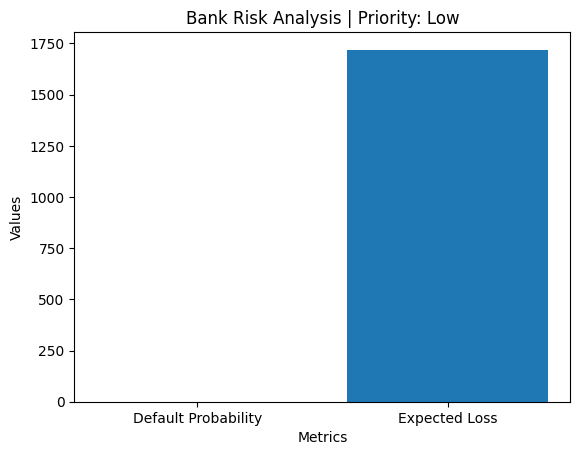

In [12]:
plt.figure()
plt.bar(["Default Probability", "Expected Loss"], [prob, loss])
plt.title(f"Bank Risk Analysis | Priority: {priority}")
plt.xlabel("Metrics")
plt.ylabel("Values")
plt.show()

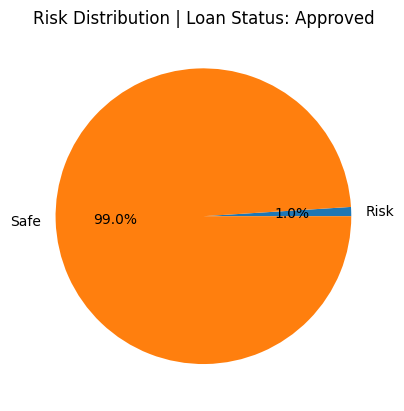

In [13]:
plt.figure()
plt.pie([prob, 1 - prob], labels=["Risk", "Safe"], autopct="%1.1f%%")
plt.title(f"Risk Distribution | Loan Status: {status}")
plt.show()

In [14]:
credit_score = raw_df["Credit_Score"].iloc[row_index]

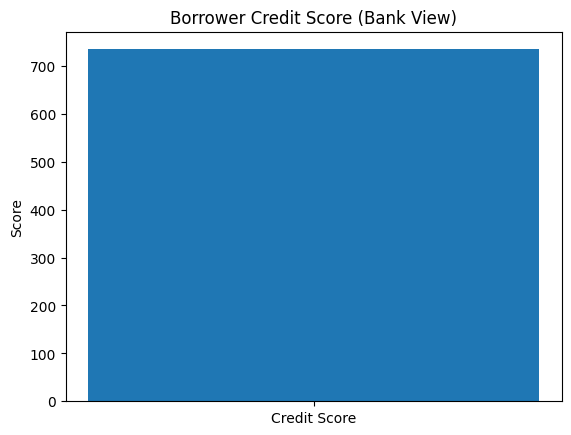

In [17]:
# ---- BAR CHART (BANK VIEW) ----
plt.figure()
plt.bar(["Credit Score"], [credit_score])
plt.title("Borrower Credit Score (Bank View)")
plt.ylabel("Score")
plt.show()

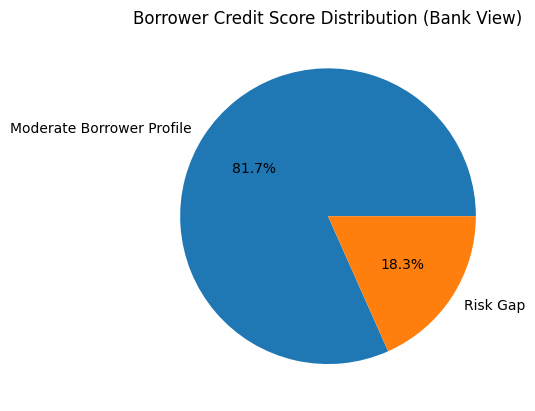

In [18]:
# ---- CREDIT SCORE CATEGORY (BANK VIEW) ----
if credit_score > 750:
    values = [credit_score, 900 - credit_score]
    labels = ["Strong Borrower Profile", "Risk Gap"]
elif credit_score > 600:
    values = [credit_score, 900 - credit_score]
    labels = ["Moderate Borrower Profile", "Risk Gap"]
else:
    values = [credit_score, 900 - credit_score]
    labels = ["High Risk Borrower", "Risk Gap"]

plt.figure()
plt.pie(values, labels=labels, autopct="%1.1f%%")
plt.title("Borrower Credit Score Distribution (Bank View)")
plt.show()